In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

In [5]:
petase_df = pd.read_csv("/Users/dz/Documents/research/functional_residue/data/breaking/test_results_embeddings.csv").set_index("Record_ID")

In [80]:
btse_labels = "bgrbrggrbrrrrrrgyrrbbrrrrrrrrbggrgbrygrrggyyrgyyggy"

In [97]:
predictions_dir = Path("/Users/dz/Documents/research/functional_residue/data/breaking/predictions")
if not predictions_dir.exists():
    raise FileNotFoundError(f"Directory {predictions_dir} does not exist.")
prediction_files = [f for f in list(predictions_dir.glob("*.npy")) if "BTSE" in f.stem]
ids = [file.stem for file in prediction_files]
predictions = [np.load(file) for file in prediction_files]
order = np.argsort([np.max(pred) for pred in predictions])
predictions = [predictions[i] for i in order]
ids = [ids[i].replace("_prediction","") for i in order]

label = [btse_labels[int(idval.replace("BTSE","")) -1] for idval in ids]
petase_predictions = []
for recordid in ids:
    if recordid in petase_df.index:
        petase_predictions.append(petase_df.loc[recordid,"Predicted_Probability"])
    else:
        petase_predictions.append(np.nan)
petase_predictions = np.array(petase_predictions)
reorder = np.argsort(petase_predictions)[::-1]
predictions = [predictions[i] for i in reorder]
ids = [ids[i] for i in reorder]
petase_predictions = petase_predictions[reorder]
labels = [label[i] for i in reorder]
label_map = {"g" : "green",
             "b" : "blue",
             "r" : "red",
             "y" : "darkgoldenrod"}
labels = [label_map[l] for l in labels]

In [92]:
def logit(x):
    """Logit function."""
    return np.log(x / (1 - x))
def sigmoid(x):
    """Sigmoid function."""
    return 1 / (1 + np.exp(-x))

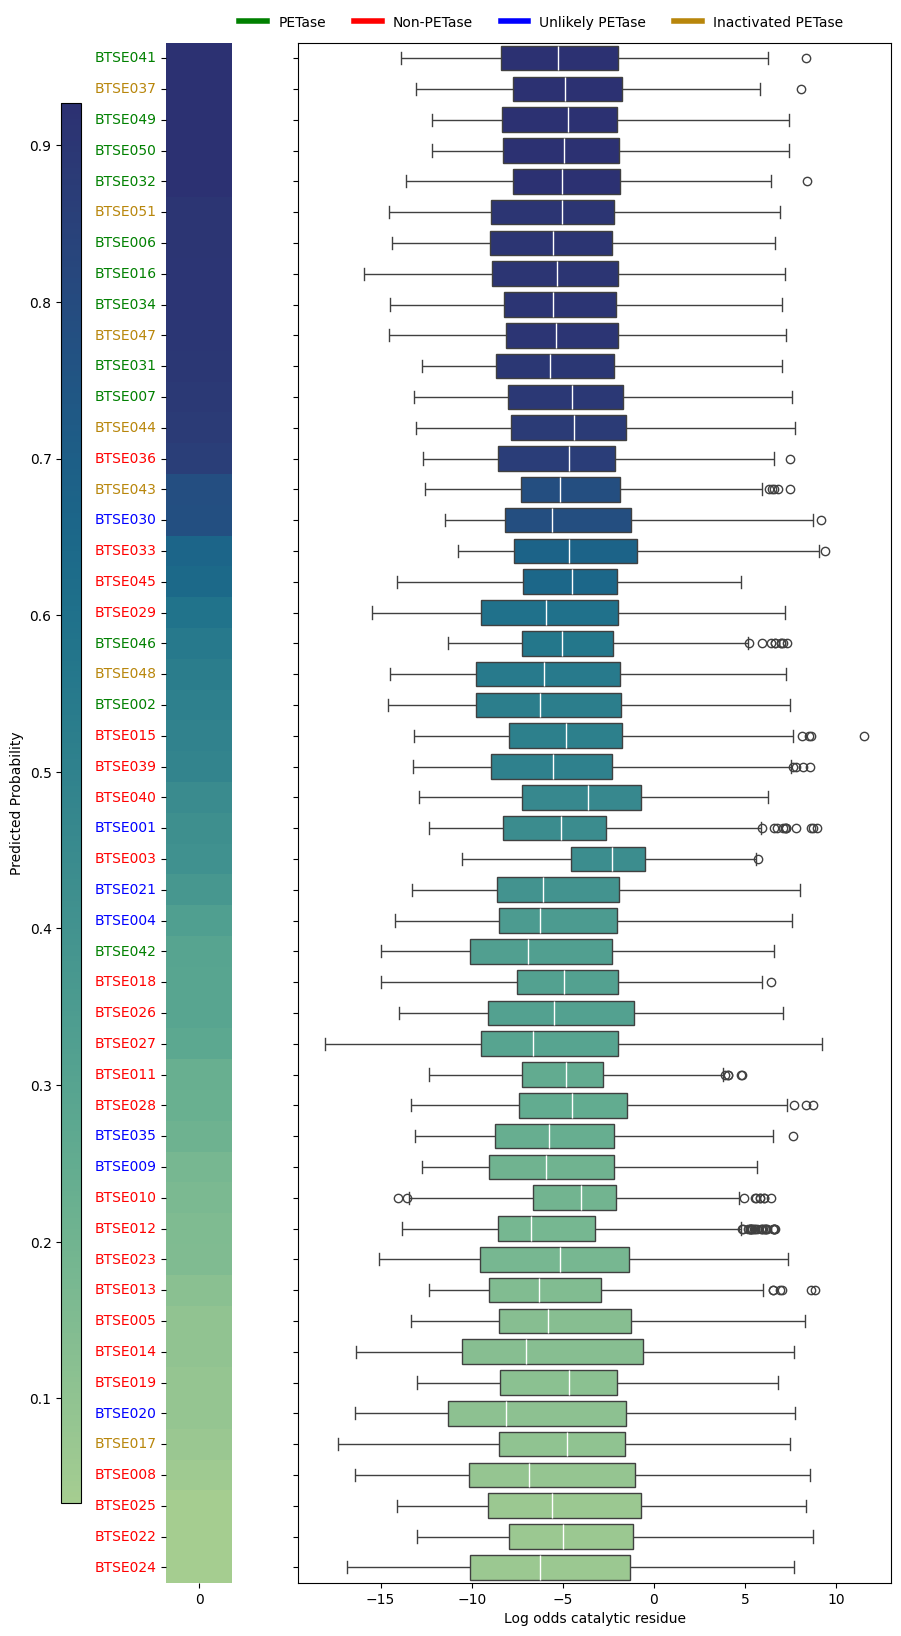

In [111]:

fig, ax = plt.subplots(1, 2, figsize=(10, 20), gridspec_kw={'width_ratios': [1, 9]})
box_results = sns.boxplot(data=[logit(p.ravel()) for p in predictions], orient='h',ax=ax[1],medianprops=dict(color='white'))

ax[1].set_xlabel("Log odds catalytic residue")
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.02, 0.15, 0.02, 0.7])
cmap = sns.color_palette("crest", as_cmap=True)
colors = cmap(petase_predictions / np.nanmax(petase_predictions))
sns.heatmap(petase_predictions.reshape((-1, 1)), ax=ax[0], cbar_ax=cbar_ax,cmap=cmap)
for patch, color in zip(box_results.patches, colors):
    if all(color == 0):
        color= "gray"
    patch.set_facecolor(color)
cbar = fig.colorbar(ax[0].collections[0], cax=cbar_ax, orientation='vertical')
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('Predicted Probability')

_ = [t.set_color(color) for t, color in zip(ax[0].get_yticklabels(), labels)]
_ = ax[0].set_yticklabels(ids, rotation=0)
_ = ax[1].set_yticklabels([])
legend_handles = [
    plt.Line2D([0], [0], color='green', lw=4, label='PETase'),
    plt.Line2D([0], [0], color='red', lw=4, label='Non-PETase'),
    plt.Line2D([0], [0], color='blue', lw=4, label='Unlikely PETase'),
    plt.Line2D([0], [0], color='darkgoldenrod', lw=4, label='Inactivated PETase'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, .9))
fig.savefig("/Users/dz/Documents/research/functional_residue/data/breaking/figures/BTSE_catalytic_residue_preds.png", dpi=300, bbox_inches='tight')

<Axes: ylabel='Count'>

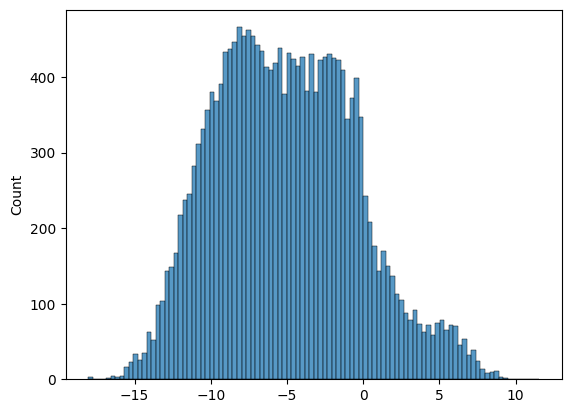

In [47]:
sns.histplot(logit(np.concatenate([p.ravel() for p in predictions])), bins=100)